# Resultados de detección de sesgo

Panel: binarios **Adult (sex)**, **Dutch Census (sex)**, **COMPAS (race)**; multiclase **OULAD (gender)**, **Communities (black)**, **Student (sex)**.

> **Antes de ejecutar: reinicia el kernel.** Python cachea los módulos ya importados, de modo que un kernel abierto desde antes de modificar `config.py` o los módulos del paquete seguirá usando la versión anterior. Si `datasets_activos()` no devuelve el panel esperado, esa es la causa.

**Lectura prudente.** La comparación externa (Le Quy et al., 2022) es **por magnitud de |SPD|**, no por valor exacto, ya que las cifras publicadas proceden de una regresión logística. DI carece de comparable externo y el *equalized odds* de esa fuente no equivale al EOD de este trabajo. Se reporta además el **baseline de clase mayoritaria**: un modelo que no lo supera no produce una disparidad interpretable.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from lamda.experiments import runner
from lamda.experiments import config as cfg
from lamda.fairness.disparity import FairnessThresholds, FairnessWeights

pd.set_option("display.float_format", "{:.4f}".format)

## Panel de configuración

Todos los parámetros del experimento se fijan aquí. Ninguna función del motor impone valores: el notebook mantiene el control completo de la configuración.

### Composición de la disparidad agregada

`D_g` se construye combinando las violaciones de umbral de SPD, EOD y DI simétrico, ponderadas por `PESOS`. Esta señal cumple dos funciones simultáneas: se reporta como medida de disparidad y **gobierna la intensidad de la penalización** de Fair-GAD y Fair-MAD. Modificarla, por tanto, no cambia solo lo que se mide, sino también el objetivo que la mitigación persigue.

Dos advertencias metodológicas antes de usar la composición por conjunto:

1. **La composición debe fijarse antes de observar los resultados** y justificarse a priori (por ejemplo, alineándola con la métrica que reporta el trabajo con el que se compara). Elegirla después de ver qué configuración favorece a las propuestas invalidaría la comparación.
2. **La comparabilidad externa no depende de esta composición.** Las métricas que se contrastan con la literatura (SPD, EOD, DI) se calculan y reportan siempre por separado, con independencia de qué entre en `D_g`.

### Normalización

Sin normalizar, `D_g` es una suma ponderada, de modo que una composición de tres métricas produce valores sistemáticamente mayores que una de dos. Esto tiene dos consecuencias: las disparidades dejan de ser comparables entre configuraciones y entre tareas (el perfil binario emplea tres componentes y el multiclase dos), y la intensidad efectiva de la penalización, que es proporcional a `lambda · D_g`, cambia al cambiar la composición.

Con `NORMALIZAR_DISPARIDAD = True` la disparidad se divide por la suma de pesos activos y queda en una escala común. **Al activarla conviene recalibrar `LAMBDA_FAIR` y `ETA_FAIR`**, ya que la señal se reduce aproximadamente en un factor igual al número de métricas empleadas.

In [2]:
# =========================================================
# 1. MODELO BASE
# =========================================================
ALPHA    = 0.65          # parámetro de exigencia
OPERATOR = "minmax"      # "product" | "minmax" | "lukasiewicz"

# =========================================================
# 2. UMBRALES DE EQUIDAD (convenciones de la literatura)
# =========================================================
THRESHOLDS = FairnessThresholds(spd=0.1, eod=0.1, di=0.8)

# =========================================================
# 3. COMPOSICIÓN DE LA DISPARIDAD D_g
# =========================================================
NORMALIZAR_DISPARIDAD = True     # divide D_g por la suma de pesos activos
CLASS_AGGREGATION     = "mean"   # "mean" | "max" (agregación sobre clases)

# Composición por defecto. Peso 0 desactiva la métrica.
COMPOSICION_DEFECTO = {"spd": 1.0, "eod": 1.0, "di": 1.0}

# Composición específica por conjunto. Debe justificarse a priori.
# DI no está definido de forma natural en multiclase: se desactiva (di=0).
COMPOSICION_POR_DATASET = {
    "adult":       {"spd": 1.0, "eod": 1.0, "di": 1.0},
    "dutch":       {"spd": 1.0, "eod": 1.0, "di": 1.0},
    "compas":      {"spd": 1.0, "eod": 1.0, "di": 1.0},
    "oulad":       {"spd": 1.0, "eod": 1.0, "di": 0.0},
    "communities": {"spd": 1.0, "eod": 1.0, "di": 0.0},
    "student":     {"spd": 1.0, "eod": 1.0, "di": 0.0},
}

# =========================================================
# 4. AYUDAS DE CONFIGURACIÓN
# =========================================================
def pesos_de(dataset: str) -> FairnessWeights:
    """Devuelve los pesos de composición de D_g aplicables a un conjunto."""
    comp = COMPOSICION_POR_DATASET.get(dataset, COMPOSICION_DEFECTO)
    return FairnessWeights(spd=comp["spd"], eod=comp["eod"], di=comp["di"],
                           normalize=NORMALIZAR_DISPARIDAD)

def descripcion_composicion(dataset: str) -> str:
    """Etiqueta legible de la composición, para trazabilidad en las tablas."""
    w = pesos_de(dataset)
    activas = [n for n, v in (("SPD", w.spd), ("EOD", w.eod), ("DI", w.di)) if v > 0]
    return " + ".join(activas) + (" (normalizada)" if w.normalize else " (sin normalizar)")

# =========================================================
# 5. ATRIBUTO SENSIBLE EN LA MATRIZ DE DESCRIPTORES
# =========================================================
# Si es True, las columnas que codifican el atributo sensible se retiran de X
# antes de entrenar. El vector de grupos sensibles se conserva siempre, ya que
# es necesario para evaluar la equidad.
EXCLUIR_ATRIBUTO_SENSIBLE = False

# =========================================================
# 6. CONJUNTOS ACTIVOS DEL PANEL
# =========================================================
# Conjuntos que se excluyen temporalmente de los barridos. OULAD se mantiene
# cargado y configurado, pero queda fuera de las ejecuciones mientras su
# rendimiento no supere el baseline de clase mayoritaria: sus medidas de
# equidad no son interpretables y su coste de ejecución es elevado.
DATASETS_EXCLUIDOS = ()

def datasets_activos() -> list:
    """Conjuntos del panel que participan en los barridos."""
    return [d for d in cfg.all_datasets() if d not in DATASETS_EXCLUIDOS]

def binarios_activos() -> list:
    """Conjuntos binarios activos."""
    return [d for d in cfg.binary_datasets() if d not in DATASETS_EXCLUIDOS]

def multiclase_activos() -> list:
    """Conjuntos multiclase activos."""
    return [d for d in cfg.multiclass_datasets() if d not in DATASETS_EXCLUIDOS]

# Partición (común a los tres modelos y a los baselines).
TEST_SIZE    = 0.2
RANDOM_STATE = 42

print("Panel:", datasets_activos())

Panel: ['adult', 'dutch', 'compas', 'oulad', 'communities', 'student']


In [3]:
# Configuración efectiva por conjunto (trazabilidad; conviene guardarla con los resultados).
traza = pd.DataFrame([
    {"Dataset": cfg.DATASETS[n].display_name, "Tarea": cfg.DATASETS[n].task,
     "Atributo": cfg.DATASETS[n].sensitive_mode,
     "Composición D_g": descripcion_composicion(n),
     "Agregación clases": CLASS_AGGREGATION}
    for n in datasets_activos()
]).set_index("Dataset")
traza

,Tarea,Atributo,Composición D_g,Agregación clases
Dataset,,,,
Adult,binary,sex,SPD + EOD + DI (normalizada),mean
Dutch Census,binary,sex,SPD + EOD + DI (normalizada),mean
COMPAS,binary,race,SPD + EOD + DI (normalizada),mean
OULAD,multiclass,gender,SPD + EOD (normalizada),mean
Communities and Crime,multiclass,black,SPD + EOD (normalizada),mean
Student Performance,multiclass,sex,SPD + EOD (normalizada),mean


## Detección para un conjunto

Inspección detallada. Cambia `DATASET` para examinar cualquiera del panel.

In [4]:
DATASET = "student"   # "adult","dutch","compas","oulad","communities","student"

result = runner.run_detection(
    dataset_name=DATASET, alpha=ALPHA, operator=OPERATOR,
    thresholds=THRESHOLDS, weights=pesos_de(DATASET),
    class_aggregation=CLASS_AGGREGATION,
    drop_sensitive_from_X=EXCLUIR_ATRIBUTO_SENSIBLE,
    test_size=TEST_SIZE, random_state=RANDOM_STATE,
)
print("Tarea:", result.task, "| composición:", descripcion_composicion(DATASET))
result.detection_table

Tarea: multiclass | composición: SPD + EOD (normalizada)


,n,Accuracy,F1_macro,F1_weighted,F1_binary,mean_disparity,max_disparity,mean_abs_spd,max_abs_spd,mean_abs_eod,max_abs_eod,mean_di,min_di,mean_spd_multiclass,max_spd_multiclass,mean_meo,max_meo
Modelo,,,,,,,,,,,,,,,,,
LAMDA clásico,130,0.5077,0.4721,0.5034,NaN,0.0177,0.0177,0.0746,0.1119,0.1176,0.1825,1.0295,0.7081,0.0746,0.0746,0.1321,0.1321


## Matriz de confusión del clásico (diagnóstico)

Ayuda a interpretar la disparidad: si el modelo colapsa a una clase o predice peor que la mayoritaria, la disparidad observada debe leerse con cautela.

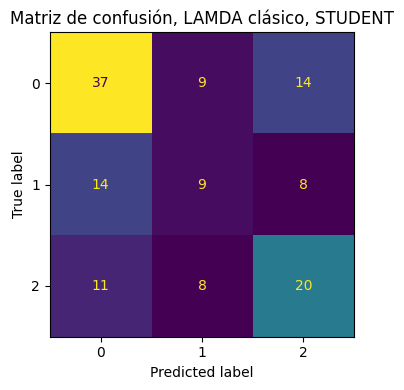

In [5]:
y_test = result.predictions["y_test"]
y_pred = result.predictions["classic"]
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, y_pred)).plot(ax=ax, colorbar=False)
ax.set_title(f"Matriz de confusión, LAMDA clásico, {DATASET.upper()}")
plt.tight_layout(); plt.show()

## Detalle por grupo y clase

Se incorporan los soportes de cada grupo y de cada par grupo-clase en el conjunto de test, ya que una fila con soporte reducido no admite la misma lectura que una con soporte amplio. El resultado se persiste como `resultados/{dataset}_detalle_grupo_clase.csv`.

In [6]:
import os
from lamda.experiments import reporting

y_true_d = result.predictions["y_test"]
y_pred_d = result.predictions["classic"]
s_d      = result.predictions["sensitive_test"]

detalle = reporting.flatten_group_class_report(
    reporting.compute_group_class_fairness(
        y_true_d, y_pred_d, s_d,
        thresholds=THRESHOLDS, weights=pesos_de(DATASET),
    )
)

# Impacto dispar en su versión habitual, con el mismo desglose.
detalle = detalle.merge(
    reporting.compute_normal_di_df(y_true_d, y_pred_d, s_d),
    on=["group", "target_class"], how="left",
)

# Soportes en test, necesarios para valorar la fiabilidad de cada fila.
s_arr, y_arr = np.asarray(s_d), np.asarray(y_true_d)
detalle["n_grupo"] = [int((s_arr == g).sum()) for g in detalle["group"]]
detalle["n_grupo_clase"] = [
    int(((s_arr == g) & (y_arr == c)).sum())
    for g, c in zip(detalle["group"], detalle["target_class"])
]

detalle = detalle[["group", "target_class", "n_grupo", "n_grupo_clase",
                   "spd", "eod", "di", "disparity"]].round(4)
os.makedirs(cfg.RESULTS_DIR, exist_ok=True)
detalle.to_csv(os.path.join(cfg.RESULTS_DIR, f"{DATASET}_detalle_grupo_clase.csv"), index=False)
print(f"Detalle de {DATASET} | composición: {descripcion_composicion(DATASET)}")
detalle

Detalle de student | composición: SPD + EOD (normalizada)


,group,target_class,n_grupo,n_grupo_clase,spd,eod,di,disparity
0,F,0,70,30,0.1119,0.1000,1.2686,0.0060
1,F,1,70,19,0.0000,-0.0702,1.0000,0.0000
2,F,2,70,21,-0.1119,-0.1825,0.7081,0.0472
3,M,0,60,30,-0.1119,-0.1000,0.7883,0.0060
4,M,1,60,12,0.0000,0.0702,1.0000,0.0000
5,M,2,60,18,0.1119,0.1825,1.4123,0.0472


## Detección para el panel completo

Recorre los seis conjuntos aplicando a cada uno su composición, persiste `resultados/{dataset}_deteccion.csv` y conserva los resultados para las tablas siguientes.

In [7]:
detection_results = {}
for name in datasets_activos():
    res = runner.run_detection(
        dataset_name=name, alpha=ALPHA, operator=OPERATOR,
        thresholds=THRESHOLDS, weights=pesos_de(name),
        class_aggregation=CLASS_AGGREGATION,
        drop_sensitive_from_X=EXCLUIR_ATRIBUTO_SENSIBLE,
        test_size=TEST_SIZE, random_state=RANDOM_STATE,
    )
    detection_results[name] = res
    runner.persist_result(res, results_dir=cfg.RESULTS_DIR)
    print(f"[{name}] tarea={res.task} | {descripcion_composicion(name)} -> persistido")
print("\nDetección completada.")

[adult] tarea=binary | SPD + EOD + DI (normalizada) -> persistido
[dutch] tarea=binary | SPD + EOD + DI (normalizada) -> persistido
[compas] tarea=binary | SPD + EOD + DI (normalizada) -> persistido
[oulad] tarea=multiclass | SPD + EOD (normalizada) -> persistido
[communities] tarea=multiclass | SPD + EOD (normalizada) -> persistido
[student] tarea=multiclass | SPD + EOD (normalizada) -> persistido

Detección completada.


## Aprendibilidad frente al baseline de clase mayoritaria

Referencia de rendimiento. `Supera trivial = False` indica que la baja disparidad no es interpretable como equidad, sino artefacto de un clasificador que no discrimina entre clases.

In [8]:
rows = []
for name in datasets_activos():
    Xtr, Xte, ytr, yte, *_ = runner.load_and_split(
        name, test_size=TEST_SIZE, random_state=RANDOM_STATE,
        drop_sensitive_from_X=EXCLUIR_ATRIBUTO_SENSIBLE)
    maj = Counter(np.asarray(ytr).tolist()).most_common(1)[0][0]
    trivial = float((np.asarray(yte) == maj).mean())
    acc = float(detection_results[name].detection_table.iloc[0]["Accuracy"])
    rows.append({"Dataset": cfg.DATASETS[name].display_name, "Accuracy LAMDA": acc,
                 "Baseline mayoritaria": trivial, "Supera trivial": acc > trivial})
aprendibilidad = pd.DataFrame(rows).set_index("Dataset")
aprendibilidad

,Accuracy LAMDA,Baseline mayoritaria,Supera trivial
Dataset,,,
Adult,0.7654,0.7510,True
Dutch Census,0.7282,0.5239,True
COMPAS,0.6117,0.5294,True
OULAD,0.2871,0.3757,False
Communities and Crime,0.5564,0.3409,True
Student Performance,0.5077,0.4615,True


In [9]:
from sklearn.metrics import f1_score

rows = []
for name in datasets_activos():
    Xtr, Xte, ytr, yte, *_ = runner.load_and_split(
        name, test_size=TEST_SIZE, random_state=RANDOM_STATE,
        drop_sensitive_from_X=EXCLUIR_ATRIBUTO_SENSIBLE)

    # Predictor trivial: asigna siempre la clase mayoritaria de entrenamiento.
    maj = Counter(np.asarray(ytr).tolist()).most_common(1)[0][0]
    y_trivial = np.full_like(np.asarray(yte), maj)

    trivial_acc = float((np.asarray(yte) == maj).mean())
    trivial_f1 = float(f1_score(yte, y_trivial, average="macro", zero_division=0))

    fila = detection_results[name].detection_table.iloc[0]
    acc = float(fila["Accuracy"])
    f1 = float(fila["F1_macro"])

    rows.append({"Dataset": cfg.DATASETS[name].display_name,
                 "Accuracy LAMDA": acc, "Accuracy trivial": trivial_acc,
                 "F1 macro LAMDA": f1, "F1 macro trivial": trivial_f1,
                 # El criterio se evalúa sobre la F1 macro: bajo desbalance la
                 # exactitud del predictor trivial no es un listón informativo.
                 "Supera trivial": f1 > trivial_f1})

aprendibilidad = pd.DataFrame(rows).set_index("Dataset")
aprendibilidad.round(4)

,Accuracy LAMDA,Accuracy trivial,F1 macro LAMDA,F1 macro trivial,Supera trivial
Dataset,,,,,
Adult,0.7654,0.7510,0.7127,0.4289,True
Dutch Census,0.7282,0.5239,0.7282,0.3438,True
COMPAS,0.6117,0.5294,0.5985,0.3461,True
OULAD,0.2871,0.3757,0.2707,0.1366,True
Communities and Crime,0.5564,0.3409,0.5530,0.1695,True
Student Performance,0.5077,0.4615,0.4721,0.2105,True


In [10]:
# Resumen de detección, conjuntos binarios.
bin_rows = []
for name in binarios_activos():
    r = detection_results[name].detection_table.iloc[0]
    bin_rows.append({"Dataset": cfg.DATASETS[name].display_name, "Accuracy": r["Accuracy"],
                     "mean_abs_spd": r["mean_abs_spd"], "max_abs_spd": r["max_abs_spd"],
                     "mean_abs_eod": r["mean_abs_eod"], "max_abs_eod": r["max_abs_eod"],
                     "DI medio": r["mean_di"], "DI mínimo": r["min_di"],
                     "D_g medio": r["mean_disparity"], "Composición": descripcion_composicion(name)})
pd.DataFrame(bin_rows).set_index("Dataset")

,Accuracy,mean_abs_spd,max_abs_spd,mean_abs_eod,max_abs_eod,DI medio,DI mínimo,D_g medio,Composición
Dataset,,,,,,,,,
Adult,0.7654,0.1817,0.1817,0.0796,0.1011,1.1249,0.5238,0.0780,SPD + EOD + DI (normalizada)
Dutch Census,0.7282,0.1724,0.1724,0.0344,0.0417,1.0625,0.6852,0.0559,SPD + EOD + DI (normalizada)
COMPAS,0.6117,0.3330,0.3330,0.3171,0.3695,1.4403,0.3130,0.2633,SPD + EOD + DI (normalizada)


In [11]:
# Resumen de detección, conjuntos multiclase.
# SPD multiclase y MEO se reportan solo en su valor medio: al venir ya
# agregadas sobre clases y haber dos grupos sensibles, su máximo coincide
# siempre con la media y no aportaría información.
mc_rows = []
for name in multiclase_activos():
    r = detection_results[name].detection_table.iloc[0]
    mc_rows.append({"Dataset": cfg.DATASETS[name].display_name, "Accuracy": r["Accuracy"],
                    "mean_spd_multiclass": r.get("mean_spd_multiclass", float("nan")),
                    "mean_meo": r.get("mean_meo", float("nan")),
                    # Métricas uno contra el resto: son las que componen la
                    # disparidad agregada en el perfil multiclase. Se reportan
                    # en valor medio y máximo porque, a diferencia de SPD
                    # multiclase y MEO, se calculan por par de grupo y clase y
                    # su máximo sí aporta información con dos grupos sensibles.
                    "|SPD| medio OvR": r["mean_abs_spd"],
                    "|SPD| máximo OvR": r["max_abs_spd"],
                    "|EOD| medio OvR": r["mean_abs_eod"],
                    "|EOD| máximo OvR": r["max_abs_eod"],
                    "D_g medio": r["mean_disparity"], "Composición": descripcion_composicion(name)})
pd.DataFrame(mc_rows).set_index("Dataset")

,Accuracy,mean_spd_multiclass,mean_meo,|SPD| medio OvR,|SPD| máximo OvR,|EOD| medio OvR,|EOD| máximo OvR,D_g medio,Composición
Dataset,,,,,,,,,
OULAD,0.2871,0.0280,0.0532,0.0280,0.0542,0.0312,0.0505,0.0000,SPD + EOD (normalizada)
Communities and Crime,0.5564,0.2536,0.2865,0.2536,0.3804,0.1264,0.3276,0.1230,SPD + EOD (normalizada)
Student Performance,0.5077,0.0746,0.1321,0.0746,0.1119,0.1176,0.1825,0.0177,SPD + EOD (normalizada)


## Comparación con la literatura (por magnitud de |SPD|)

Cifras **verificadas** en Le Quy et al. (2022), Tabla 15 (regresión logística). Solo conjuntos binarios: la literatura emplea los multiclase en versión binarizada, por lo que no existe comparable de cifras para su versión multiclase. Esa ausencia es estructural y motiva el trabajo.

In [12]:
LIT_SPD_ABS = {
    "adult":  {"spd": 0.0555, "attr": "sex",  "acc": 0.7864},
    "dutch":  {"spd": 0.3568, "attr": "sex",  "acc": 0.8149},
    "compas": {"spd": 0.3398, "attr": "race", "acc": 0.6414},
}
rows = []
for name in datasets_activos():
    r = detection_results[name].detection_table.iloc[0]
    lit = LIT_SPD_ABS.get(name)
    rows.append({"Dataset": cfg.DATASETS[name].display_name,
                 "Atributo": lit["attr"] if lit else cfg.DATASETS[name].sensitive_mode,
                 "|SPD| LAMDA": float(r["mean_abs_spd"]),
                 "|SPD| literatura": lit["spd"] if lit else np.nan,
                 "Accuracy literatura": lit["acc"] if lit else np.nan,
                 "Fuente": "Le Quy et al. (2022), Tabla 15" if lit else "sin comparable (multiclase)"})
comparacion_literatura = pd.DataFrame(rows).set_index("Dataset")
comparacion_literatura

,Atributo,|SPD| LAMDA,|SPD| literatura,Accuracy literatura,Fuente
Dataset,,,,,
Adult,sex,0.1817,0.0555,0.7864,"Le Quy et al. (2022), Tabla 15"
Dutch Census,sex,0.1724,0.3568,0.8149,"Le Quy et al. (2022), Tabla 15"
COMPAS,race,0.3330,0.3398,0.6414,"Le Quy et al. (2022), Tabla 15"
OULAD,gender,0.0280,NaN,NaN,sin comparable (multiclase)
Communities and Crime,black,0.2536,NaN,NaN,sin comparable (multiclase)
Student Performance,sex,0.0746,NaN,NaN,sin comparable (multiclase)
